In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from classes import Problem, Boat, Trip
import seaborn as sns
# import scikit_posthocs as sp

In [3]:
records = []
with open("original_mip_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_mip_orig = pd.DataFrame(records)
df_mip_orig["bound_gap"] = (df_mip_orig["best_obj"]-df_mip_orig["best_bound"])/df_mip_orig["best_bound"]*100
# display(df_mip_orig[df_mip_orig['problem_id'].isin([28, 29, 31])])
display(df_mip_orig)

,problem_id,num_stations,max_work,num_boats,percentage_kept,num_dummy_ports,node_compression,num_continuous_vars,num_integer_vars,num_binary_vars,num_constraints,work_units_used,runtime,best_obj,best_bound,best_solution,solution_log,bound_gap
0,35,20,20,1,100,3,True,1981,380.0,1895,2557,489.937439,1200.423,76.255911,73.312004,"[(12, 274), (257, 258), (258, 246), (229, 230)...","[(0.03699994087219238, 1e+100, 23.103429539298...",4.015586e+00
1,35,20,20,1,75,3,True,1701,294.0,1575,2191,325.769457,1200.192,76.255908,73.504953,"[(12, 274), (257, 258), (258, 246), (229, 230)...","[(0.0710000991821289, 1e+100, 23.1034295392983...",3.742544e+00
2,35,20,20,1,50,3,True,1333,192.0,1175,1721,323.040361,1200.167,76.299337,74.065168,"[(12, 226), (257, 258), (258, 246), (229, 230)...","[(0.09299993515014648, 1e+100, 23.103429539298...",3.016490e+00
3,35,20,20,1,25,3,True,953,93.0,775,1242,53.260734,130.784,76.331074,76.331074,"[(12, 302), (257, 258), (258, 246), (229, 230)...","[(0.0410001277923584, 1e+100, 23.1034295392983...",1.861739e-14
4,35,20,20,1,10,3,True,696,31.0,538,927,1.610719,2.674,90.239271,90.239271,"[(12, 248), (257, 258), (258, 286), (229, 225)...","[(0.0410001277923584, 1e+100, 23.1034295392983...",0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,0,581,150,4,75,2,True,1863810,NaN,980382,1760882,944.566360,1200.380,NaN,1141.268123,NaN,"[(43.348999977111816, 1e+100, 662.453656513780...",NaN
242,0,581,150,4,50,2,True,1368366,NaN,650758,1183368,1160.027363,1200.342,NaN,1141.268124,NaN,"[(28.09999990463257, 1e+100, 662.4536565137802...",NaN
243,0,581,150,4,25,2,True,937410,NaN,363614,680632,1294.861003,1200.316,NaN,1141.268125,NaN,"[(14.950000047683716, 1e+100, 662.453656513780...",NaN
244,0,581,150,4,10,2,True,662670,NaN,180674,359924,1869.569183,1200.339,NaN,1151.375755,NaN,"[(13.545000076293945, 1e+100, 662.453656513780...",NaN


In [4]:
df_mip = df_mip_orig.copy()
print(len(df_mip[df_mip['num_stations'] == 200]))
for p in [1, 5, 10, 25, 50, 75, 100]:
    print(f'{p}%: {len(df_mip[df_mip['num_stations'] == 200][df_mip['percentage_kept'] == p]['best_obj'].value_counts())}')
# len2 = len(df_mip[df_mip['num_stations'] == 100]['best_obj'].value_counts())
# print(len1)
# print(len2)

42
1%: 6
5%: 2
10%: 0
25%: 0
50%: 0
75%: 0
100%: 0


C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\475801538.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'{p}%: {len(df_mip[df_mip['num_stations'] == 200][df_mip['percentage_kept'] == p]['best_obj'].value_counts())}')
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\475801538.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'{p}%: {len(df_mip[df_mip['num_stations'] == 200][df_mip['percentage_kept'] == p]['best_obj'].value_counts())}')
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\475801538.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'{p}%: {len(df_mip[df_mip['num_stations'] == 200][df_mip['percentage_kept'] == p]['best_obj'].value_counts())}')
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\475801538.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'{p}%: {len(df_mip[df_mip['num_stations'] == 200][df_mip[

C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\15863914.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  valid_ids = df_mip[df_mip['percentage_kept'] == 100][df_mip['best_obj'] > 0]['problem_id'].unique()


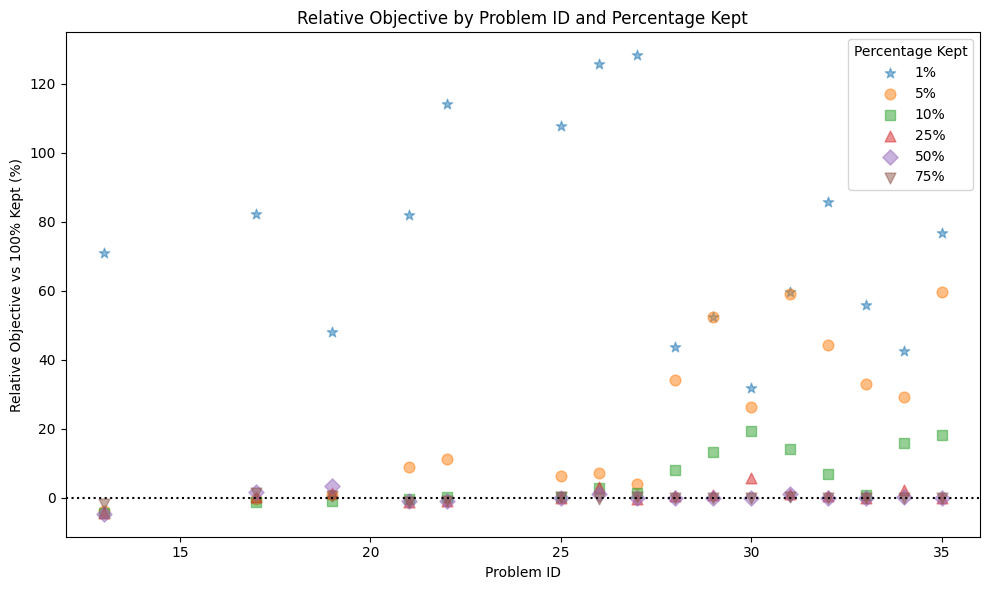

In [5]:
df_mip = df_mip_orig.copy()
df_mip = df_mip[df_mip['percentage_kept'] > 0]
# Filter for problem_ids that have a best_obj for 100% kept
valid_ids = df_mip[df_mip['percentage_kept'] == 100][df_mip['best_obj'] > 0]['problem_id'].unique()
df_plot = df_mip[df_mip['problem_id'].isin(valid_ids)].copy()

# Compute best_obj for 100% kept per problem_id
best_obj_100 = df_plot[df_plot['percentage_kept'] == 100].groupby('problem_id')['best_obj'].min()
df_plot['best_obj_100'] = df_plot['problem_id'].map(best_obj_100)

# Compute relative difference (0 for 100%, >0 for others)
df_plot['relative_obj'] = (df_plot['best_obj'] - df_plot['best_obj_100']) / df_plot['best_obj_100'] * 100
df_plot.loc[df_plot['percentage_kept'] == 100, 'relative_obj'] = 0

# Define marker shapes for each percentage_kept value
percentages = sorted(df_plot['percentage_kept'].unique())
markers = ['*', 'o', 's', '^', 'D', 'v', 'P', 'X'] # 6 shapes

plt.figure(figsize=(10, 6))
for perc, marker in zip(percentages, markers):
    if perc == 100:
        continue
    subset = df_plot[df_plot['percentage_kept'] == perc]
    plt.scatter(
        subset['problem_id'],
        subset['relative_obj'],
        marker=marker,
        s=60,
        label=f'{perc}%',
        alpha=0.5
    )
    # print(f'{perc}: {subset['relative_obj'].values}')
# plt.yscale('log')
plt.hlines(0, 12, 37.5, linestyles='dotted', colors='black', alpha=1)
plt.xlim([12, 36])
plt.xlabel('Problem ID')
plt.ylabel('Relative Objective vs 100% Kept (%)')
plt.title('Relative Objective by Problem ID and Percentage Kept')
plt.legend(title='Percentage Kept', loc='best')
plt.tight_layout()
plt.show()

,problem_id,num_stations,max_work,num_boats,percentage_kept,num_dummy_ports,node_compression,num_continuous_vars,num_integer_vars,num_binary_vars,num_constraints,work_units_used,runtime,best_obj,best_bound,best_solution,solution_log,bound_gap


percentage_kept,1,5,10,25,50,75,100
num_stations,,,,,,,
20,1057.0,1054.0,988.0,1238.0,1729.0,2187.0,2559.0
50,7111.0,2965.0,3448.0,5357.0,8456.0,11550.0,14240.0
100,14058.0,8990.0,11640.0,19190.0,31706.0,43946.0,55310.0
200,9956.0,18397.0,28522.0,58420.0,108431.0,158905.0,206323.0
581,NaN,653028.0,728346.0,976579.0,1394366.0,1863810.0,2510658.0


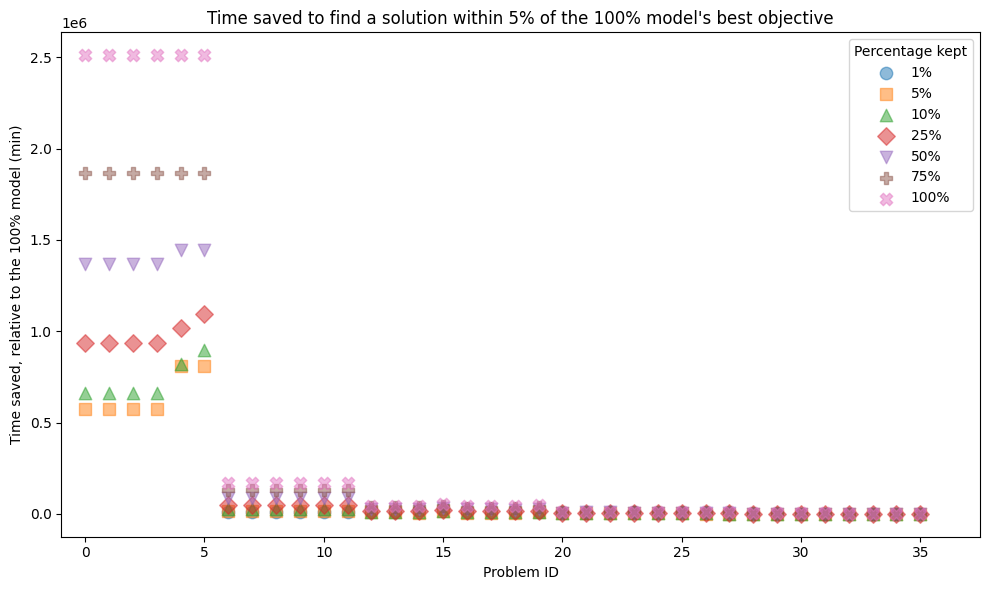

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# assume df has columns: problem_id, percentage_kept, best_obj, solution_log (list of (time, incumbent, bound))

results = []
df = df_mip_orig.copy()
display(df[(df['percentage_kept'] == 1) & (df['num_stations'] == 581)])
pivot_table = df.groupby(['percentage_kept', 'num_stations'])[['num_continuous_vars', 'num_integer_vars']].mean().sum(axis=1).unstack('percentage_kept')
display(pivot_table.round(0))

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']  # different shapes for different percentages

for (perc, data), marker in zip(sorted(df.groupby('percentage_kept')), markers):
    ax.scatter(data['problem_id'], data['num_continuous_vars'], label=f'{perc}%', marker=marker, s=80, alpha=0.5)

plt.style.use('default')
ax.set_xlabel('Problem ID')
ax.set_ylabel("Time saved, relative to the 100% model (min)")
ax.set_title("Time saved to find a solution within 5% of the 100% model's best objective")
ax.legend(title='Percentage kept')
# plt.hlines(0, -1, 37.5, linestyles='dotted', colors='black', alpha=1)
plt.xlim([-1, 37.5])
plt.tight_layout()
plt.show()


60


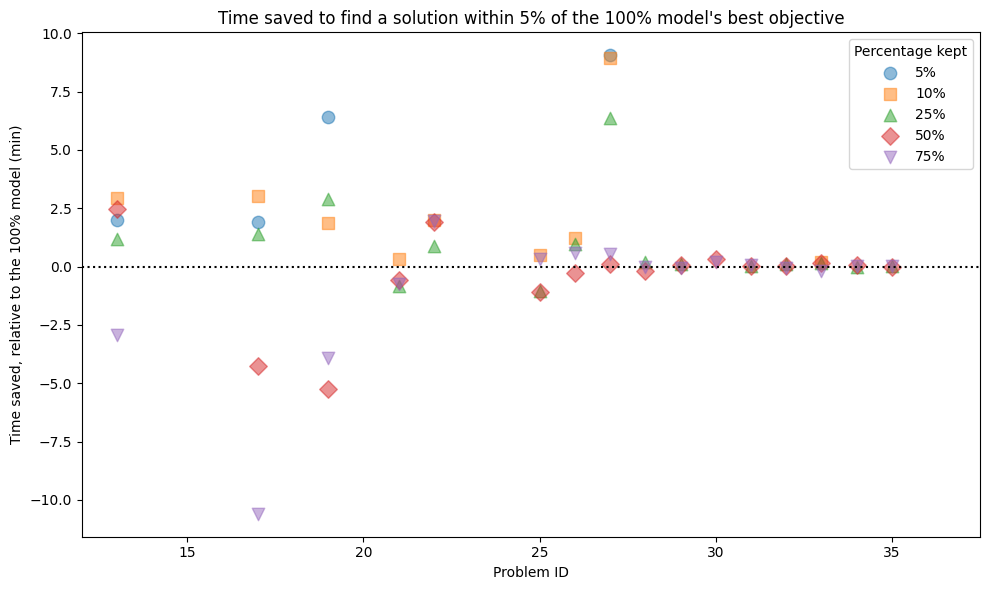

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# assume df has columns: problem_id, percentage_kept, best_obj, solution_log (list of (time, incumbent, bound))

results = []
df = df_mip_orig.copy()

count = 0
for pid, group in df.groupby('problem_id'):
    # --- Find the best objective from 100% kept ---
    ref_row = group[group['percentage_kept'] == 100]
    if ref_row.empty:
        continue
    best_obj_100 = ref_row['best_obj'].values[0]*1.05
    
    # Get time when 100% kept reached this best objective
    log_100 = eval(ref_row['solution_log'].values[0])
    # print(log_100)
    time_100 = None
    for t, inc, _ in log_100:
        if inc <= best_obj_100:
            time_100 = t
            break

    if time_100 is None:
        continue

    # Add reference point (optional)
    # results.append({
    #     'problem_id': pid,
    #     'percentage_kept': 100,
    #     'time': time_100 - time_100
    # })

    # --- For other percentages ---
    for perc, sub in group[group['percentage_kept'] != 100].groupby('percentage_kept'):
        log = eval(sub['solution_log'].values[0])
        time_found = None
        for t, inc, _ in log:
            if inc <= best_obj_100:
                time_found = t
                break
        if time_found is not None:
            results.append({
                'problem_id': pid,
                'percentage_kept': perc,
                'time': (time_100 - time_found)/60
            })
            count += 1
print(count)


# Convert to dataframe for plotting
plot_df = pd.DataFrame(results)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']  # different shapes for different percentages

for (perc, data), marker in zip(sorted(plot_df.groupby('percentage_kept')), markers):
    ax.scatter(data['problem_id'], data['time'], label=f'{perc}%', marker=marker, s=80, alpha=0.5)

plt.style.use('default')
ax.set_xlabel('Problem ID')
ax.set_ylabel("Time saved, relative to the 100% model (min)")
ax.set_title("Time saved to find a solution within 5% of the 100% model's best objective")
ax.legend(title='Percentage kept')
plt.hlines(0, 12, 37.5, linestyles='dotted', colors='black', alpha=1)
plt.xlim([12, 37.5])
plt.tight_layout()
plt.show()


In [8]:
df_mip = df_mip_orig.copy()
plt.figure(figsize=(10, 6))
prob_id = 25
obj_100 = df_mip[df_mip['problem_id'] == prob_id][df_mip['percentage_kept'] == 100]['best_obj'].iloc[0]
for p in [1, 5, 10, 25, 50, 75, 100]:
    sol_log = eval(df_mip[df_mip['problem_id'] == prob_id][df_mip['percentage_kept'] == p]['solution_log'].iloc[0])
    time_met = [sol[0] for sol in sol_log if sol[1] <= obj_100+1e-8]
    if len(time_met) > 0:
        print(f'{p}: {min(time_met)}')
    else:
        print(f'{p}: N/A')
    # time_list = [sol[0] for sol in sol_log if sol[1] < 1000]
    # obj_list = [sol[1] for sol in sol_log if sol[1] < 1000]
    # bound_list = [sol[2] for sol in sol_log if sol[1] < 1000]
    # plt.scatter(time_list, obj_list, s=10)
    # plt.scatter(time_list, bound_list, s=10)

1: N/A
5: N/A
10: N/A
25: N/A
50: 563.3650000095367
75: N/A
100: 615.4629998207092


C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\1537551445.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  obj_100 = df_mip[df_mip['problem_id'] == prob_id][df_mip['percentage_kept'] == 100]['best_obj'].iloc[0]
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\1537551445.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sol_log = eval(df_mip[df_mip['problem_id'] == prob_id][df_mip['percentage_kept'] == p]['solution_log'].iloc[0])
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\1537551445.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sol_log = eval(df_mip[df_mip['problem_id'] == prob_id][df_mip['percentage_kept'] == p]['solution_log'].iloc[0])
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\1537551445.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sol_log = eval(df_mip[df_mip['problem_id'] == prob_id][df_mip['percentage_kept'] == p]['solu

<Figure size 1000x600 with 0 Axes>

6         0.297
13        0.307
20        0.204
27        0.225
34        1.112
41        0.376
48        0.662
55        0.367
62        3.175
69        2.391
76        1.589
83        1.640
90        7.745
97       12.517
104      10.648
111      10.131
118      32.583
125      11.707
132      34.483
146     141.668
153      35.643
160      10.801
174    1030.141
181     340.207
188    1201.799
195    1200.491
202    1200.424
209    1200.927
Name: runtime, dtype: float64


C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\497587540.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df_mip[df_mip['percentage_kept'] < 100][df_mip['percentage_kept'] > 0],
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\497587540.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\497587540.py:45: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  ax = sns.boxplot(
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\497587540.py:79: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df_mip[df_mip['percentage_kept'] < 100][df_mip['percentage_kept'] > 0],
C:\Users\saahi\AppData\Local\Temp\ipykernel_35936\497587540.py:78: FutureWarning: 

Passing `palette` wi

problem_id                                                            17
num_stations                                                          20
max_work                                                              12
num_boats                                                              1
percentage_kept                                                       50
num_dummy_ports                                                        2
node_compression                                                    True
num_continuous_vars                                                 1230
num_integer_vars                                                   185.0
num_binary_vars                                                     1088
num_constraints                                                     1607
work_units_used                                                33.144349
runtime                                                           58.692
best_obj                                           

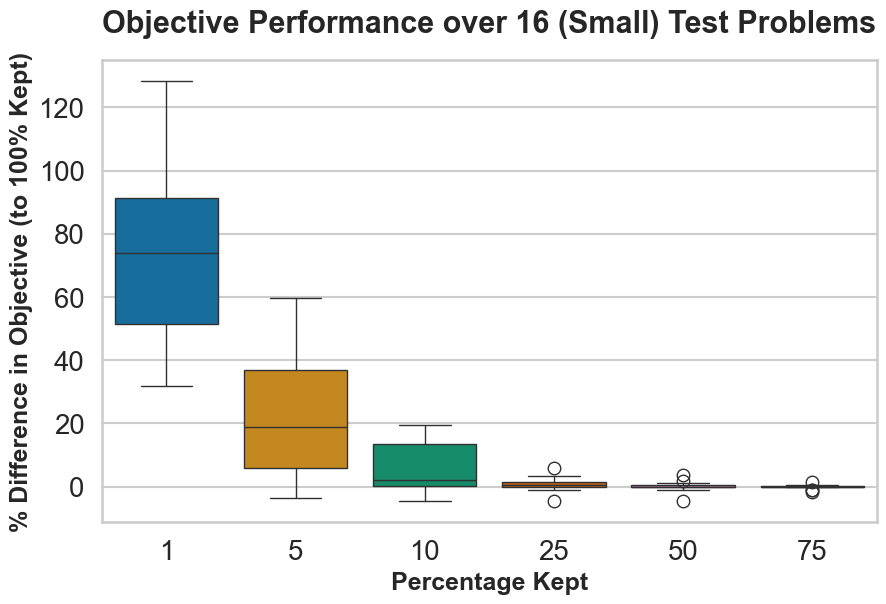

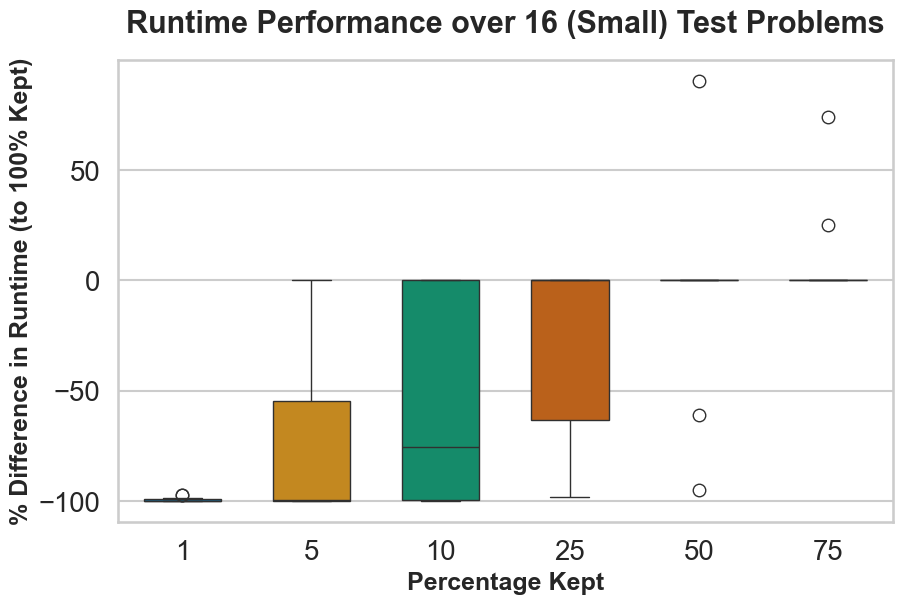

In [9]:
# Start from a clean copy
df_mip = df_mip_orig.copy()

# ✅ Filter valid rows once
df_mip = df_mip[(df_mip['best_obj'] > 0) & (df_mip['percentage_kept'] > 0)]

# ✅ Compute best objective for 100% per problem_id
best_100 = (
    df_mip[df_mip['percentage_kept'] == 100]
    .groupby('problem_id')['best_obj']
    .min()
)

# ✅ Map 100% best objective to all rows in same problem_id
df_mip['best_obj_100'] = df_mip['problem_id'].map(best_100)

time_100 = (
    df_mip[df_mip['percentage_kept'] == 100]
    .groupby('problem_id')['runtime']
    .min()
)

# ✅ Map 100% best objective to all rows in same problem_id
df_mip['time_100'] = df_mip['problem_id'].map(time_100)

# ✅ Compute relative difference (% worse than 100%)
df_mip['relative_diff'] = (
    (df_mip['best_obj'] - df_mip['best_obj_100'])
    / df_mip['best_obj_100'] * 100
)

df_mip['relative_time'] = (
    (df_mip['runtime'] - df_mip['time_100'])
    / df_mip['time_100'] * 100
)

# Remove rows where best_obj_100 is NaN (problems missing 100% data)
df_mip = df_mip.dropna(subset=['best_obj_100'])

# === Boxplot ===
sns.set_theme(style="whitegrid", font_scale=1.4)
sns.set_context("talk", font_scale=1.2)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_mip[df_mip['percentage_kept'] < 100][df_mip['percentage_kept'] > 0],
    x='percentage_kept',
    y='relative_diff',  # change to your actual column (e.g. 'relative_diff')
    # hue='percentage_kept',
    # marker='num_stations',
    palette=sns.color_palette("colorblind"),  # nice distinct colors
    # width=0.6,
    # linewidth=2.2,
    # fliersize=5
)

plt.xlabel("Percentage Kept", fontsize=18, fontweight='bold', fontname='Arial')
plt.ylabel("% Difference in Objective (to 100% Kept)", fontsize=18, fontweight='bold', fontname='Arial')
plt.title("Objective Performance over 16 (Small) Test Problems",
          fontsize=22, fontweight='bold', fontname='Arial', pad=20)

# print(df_mip['problem_id'].value_counts())

# plt.figure(figsize=(10, 6))
# ax = sns.scatterplot(
#     data=df_mip[df_mip['percentage_kept'] < 100][df_mip['percentage_kept'] > 5],
#     x='relative_time',
#     y='relative_diff',  # change to your actual column (e.g. 'relative_diff')
#     hue='percentage_kept',
#     # marker='num_stations',
#     palette=sns.color_palette("colorblind"),  # nice distinct colors
#     # width=0.6,
#     # linewidth=2.2,
#     # fliersize=5
# )

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_mip[df_mip['percentage_kept'] < 100][df_mip['percentage_kept'] > 0],
    x='percentage_kept',
    y='relative_time',  # change to your actual column (e.g. 'relative_diff')
    # hue='percentage_kept',
    # marker='num_stations',
    palette=sns.color_palette("colorblind"),  # nice distinct colors
    width=0.6,
    # linewidth=2.2,
    # fliersize=5
)

# Labels and title
plt.xlabel("Percentage Kept", fontsize=18, fontweight='bold', fontname='Arial')
plt.ylabel("% Difference in Runtime (to 100% Kept)", fontsize=18, fontweight='bold', fontname='Arial')
plt.title("Runtime Performance over 16 (Small) Test Problems",
          fontsize=22, fontweight='bold', fontname='Arial', pad=20)

print(df_mip_orig[df_mip_orig['percentage_kept'] == 1][df_mip_orig['best_obj'] > 0]['runtime'])
display(df_mip[df_mip['relative_time'] < 0][df_mip['percentage_kept'] == 50].min())

In [10]:
records = []
with open("initial_heur_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_heur_orig = pd.DataFrame(records)
# df["bound_gap"] = (df["best_obj"]-df["best_bound"])/df["best_bound"]*100

display(df_heur_orig)

,problem_id,method,num_stations,num_boats,num_iter,best_obj,best_solution,solution_log
0,35,1,40,1,6559,76.952596,"[[[12, 293, 294, 268, 267, 286, 285, 271, 272,...","[(0.21360421180725098, 78.34037178328013, 78.3..."
1,33,1,40,2,5572,87.575745,"[[[12, 300, 299, 289, 290, 279, 280, 283, 284,...","[(0.2525496482849121, 115.6803735808982, 115.6..."
2,30,1,40,1,5815,87.051857,"[[[12, 141, 142, 287, 288, 289, 290, 268, 267,...","[(0.17211079597473145, 999782.862187208, 10000..."
3,28,1,40,2,5277,102.946814,"[[[12, 298, 297, 294, 293, 282, 281, 280, 279,...","[(0.17232847213745117, 153.14152409268468, 153..."
4,27,1,100,1,1821,172.236833,"[[[11, 453, 454, 391, 392, 450, 449, 446, 445,...","[(0.7210888862609863, 206.59586550067755, 206...."
...,...,...,...,...,...,...,...,...
182,10,11,400,1,140,627.996228,"[[[4, 305, 306, 398, 397, 402, 401, 407, 408, ...","[(10.067915439605713, 746.9311012554028, 746.9..."
183,8,11,400,2,78,669.878750,"[[[4, 303, 304, 313, 314, 197, 198, 199, 200, ...","[(21.816463232040405, 736.8427203914606, 736.8..."
184,7,11,400,4,64,806.297164,"[[[4, 311, 312, 193, 194, 199, 200, 212, 211, ...","[(13.352828025817871, 829.7455735783929, 829.7..."
185,0,11,1162,4,4,1643.572212,"[[[4, 315, 316, 308, 307, 305, 306, 324, 323, ...","[(303.2403736114502, 1678.4879026137446, 1678...."


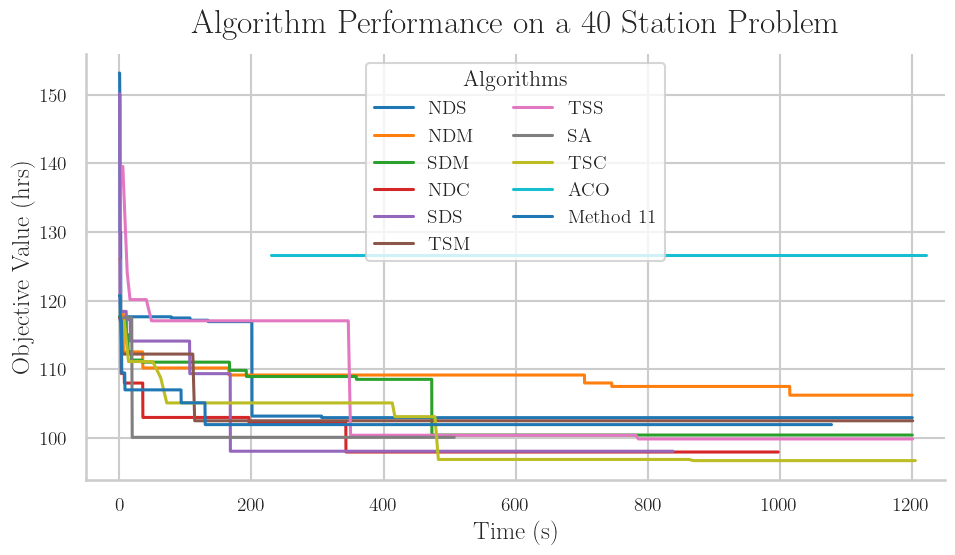

In [ ]:
for pid, group in df.groupby("problem_id"):
    if pid != 28:   # change or remove this filter if needed
        continue

    plt.figure(figsize=(10, 6))
    
    # === Build a combined long-form dataframe for seaborn ===
    all_logs = []
    for method in group['method'].values:
        if method == 0:
            continue
        df_filtered = group[group["method"] == method]
        sol_log = list(df_filtered['solution_log'].apply(lambda s: [t for t in ast.literal_eval(s)]))[0]
        
        time_vals = [s[0] for s in sol_log if s[2] < 10000]
        obj_vals = [s[2] for s in sol_log if s[2] < 10000]
        method_labels = {0: "NDS1", 1: "NDS", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO"}
        method_name = method_labels.get(method, f"Method {method}")
        
        all_logs.extend(
            {"Time (s)": t, "Objective Value (hrs)": o, "Method": method_name}
            for t, o in zip(time_vals, obj_vals)
        )
    
    plot_df = pd.DataFrame(all_logs)

    # === Line plot with seaborn ===
    sns.lineplot(
        data=plot_df,
        x="Time (s)", y="Objective Value (hrs)",
        hue="Method",
        palette="tab10", linewidth=2.2
    )

    # === Format ===
    plt.title('Algorithm Performance on a 40 Station Problem',
              fontsize=24, fontweight='bold', fontname='Arial', pad=15)
    plt.xlabel('Time (s)', fontsize=18, fontname='Arial', fontweight='bold')
    plt.ylabel('Objective Value (hrs)', fontsize=18, fontname='Arial', fontweight='bold')
    plt.xticks(fontsize=14, fontname='Arial')
    plt.yticks(fontsize=14, fontname='Arial', fontweight='bold')
    plt.xlim(-50, 1250)
    plt.legend(fontsize=14, title='Algorithms', title_fontsize=16, ncol=2)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [ ]:
df = df_heur_orig.copy()
df = df[df['method'] != 0]

pivot = df.pivot(index='problem_id', columns='method', values='best_obj').dropna()

# stat, p_value = friedmanchisquare(*[pivot[col] for col in pivot.columns])
# print(f"Friedman test statistic: {stat:.4f}")
# print(f"p-value: {p_value:.4e}")

# === RANKS ===
ranks = pivot.rank(axis=1, method='average')
display(ranks)
print(ranks[6].value_counts())
avg_ranks = ranks.mean().sort_values()
print("\nAverage ranks (lower = better):")
print(avg_ranks)

method,1,2,3,4,5,6,7,8,9,10,11
problem_id,,,,,,,,,,,
0,9.0,1.0,3.0,6.0,10.0,4.0,11.0,8.0,2.0,5.0,7.0
2,6.0,1.0,5.0,4.0,8.0,9.0,10.0,7.0,2.0,11.0,3.0
7,7.0,3.0,2.0,4.0,8.0,5.0,10.0,9.0,1.0,11.0,6.0
8,7.0,3.5,2.0,3.5,8.0,1.0,10.0,9.0,6.0,11.0,5.0
10,7.0,5.0,1.0,2.0,9.0,3.0,10.0,8.0,6.0,11.0,4.0
12,8.0,4.0,6.0,5.0,9.0,3.0,2.0,11.0,1.0,10.0,7.0
15,6.0,4.0,2.0,3.0,5.0,1.0,8.0,9.0,11.0,7.0,10.0
16,7.0,6.0,4.0,3.0,8.0,2.0,9.0,11.0,1.0,10.0,5.0
18,6.0,3.0,5.0,2.0,7.0,1.0,9.0,8.0,11.0,4.0,10.0


6
2.0    4
1.0    3
4.0    3
3.0    3
1.5    2
5.0    1
9.0    1
Name: count, dtype: int64

Average ranks (lower = better):
method
6     2.882353
4     3.294118
3     3.882353
2     4.117647
9     5.382353
11    6.764706
8     6.882353
1     7.323529
5     7.558824
7     8.617647
10    9.294118
dtype: float64


In [ ]:
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

df = df_heur_orig.copy()

df_filt = df[df['method'] != 100 & (df['num_stations'] > 0)]
pivot = df_filt.pivot(index='problem_id', columns='method', values='best_obj').dropna()

stat, p_value = friedmanchisquare(*[pivot[col] for col in pivot.columns])
print(f"Friedman test statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

# === RANKS ===
ranks = pivot.rank(axis=1, method='average')
avg_ranks = ranks.mean().sort_values()
print("\nAverage ranks (lower = better):")
print(avg_ranks)

# === POSTHOC NEMENYI ===
nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
nemenyi_df = pd.DataFrame(nemenyi, index=pivot.columns, columns=pivot.columns)
print("\nNemenyi post-hoc p-values:")
print(nemenyi_df.round(4))

# === CRITICAL DIFFERENCE DIAGRAM ===
def cd_diagram(avg_ranks, nemenyi_df, alpha=0.05):
    """
    Draws a Critical Difference diagram using average ranks and Nemenyi p-values.
    """
    k = len(avg_ranks)
    N = len(pivot)
    
    # Critical Difference (approximation)
    # q_alpha values for alpha=0.05: 2.569 for 10 algorithms (two-tailed)
    # You can adjust this constant if k changes (see Demšar 2006)
    q_alpha = 2.569  
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
    
    # Sort methods by average rank
    methods = avg_ranks.index.tolist()
    ranks = avg_ranks.values
    
    plt.figure(figsize=(10, 2))
    plt.hlines(1, min(ranks) - cd, max(ranks) + cd, color='k')
    
    # Plot methods
    for i, (method, rank) in enumerate(zip(methods, ranks)):
        plt.plot(rank, 1, 'o', markersize=8)
        plt.text(rank, 1.05, method, rotation=45, ha='center', va='bottom', fontsize=9)
    
    # Plot CD bar
    plt.hlines(1.2, max(ranks) - cd, max(ranks), linewidth=3, color='k')
    plt.text(max(ranks) - cd / 2, 1.25, f'CD = {cd:.2f}', ha='center', va='bottom')
    
    plt.title("Critical Difference (Nemenyi) Diagram")
    plt.yticks([])
    plt.xlabel("Average Rank (lower is better)")
    plt.tight_layout()
    plt.show()

# cd_diagram(avg_ranks, nemenyi_df)


Friedman test statistic: 38.1308
p-value: 3.6013e-05

Average ranks (lower = better):
method
2      3.777778
4      3.777778
3      3.888889
6      4.111111
9      5.333333
8      5.555556
11     6.055556
5      7.277778
1      7.555556
7      8.666667
10    10.000000
dtype: float64

Nemenyi post-hoc p-values:
method      1       2       3       4       5       6       7       8   \
method                                                                   
1       1.0000  1.0000  1.0000  0.4770  1.0000  0.0657  0.9885  0.9960   
2       1.0000  1.0000  1.0000  0.5282  1.0000  0.0806  0.9930  0.9978   
3       1.0000  1.0000  1.0000  0.4770  1.0000  0.0657  0.9885  0.9960   
4       0.4770  0.5282  0.4770  1.0000  0.6310  0.9984  0.9910  0.9775   
5       1.0000  1.0000  1.0000  0.6310  1.0000  0.1185  0.9978  0.9995   
6       0.0657  0.0806  0.0657  0.9984  0.1185  1.0000  0.6562  0.5540   
7       0.9885  0.9930  0.9885  0.9910  0.9978  0.6562  1.0000  1.0000   
8       0.9960  0.9978

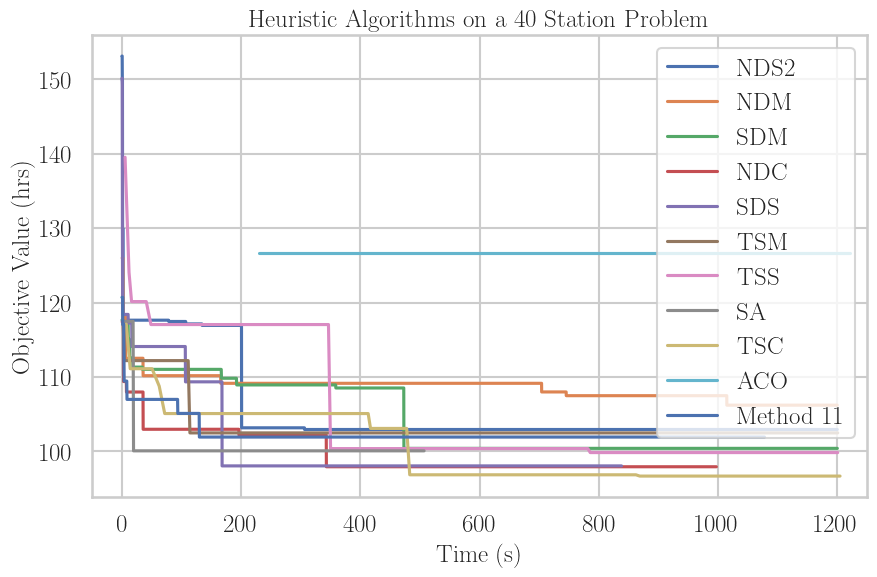

,problem_id,method,num_stations,num_boats,num_iter,best_obj,best_solution,solution_log


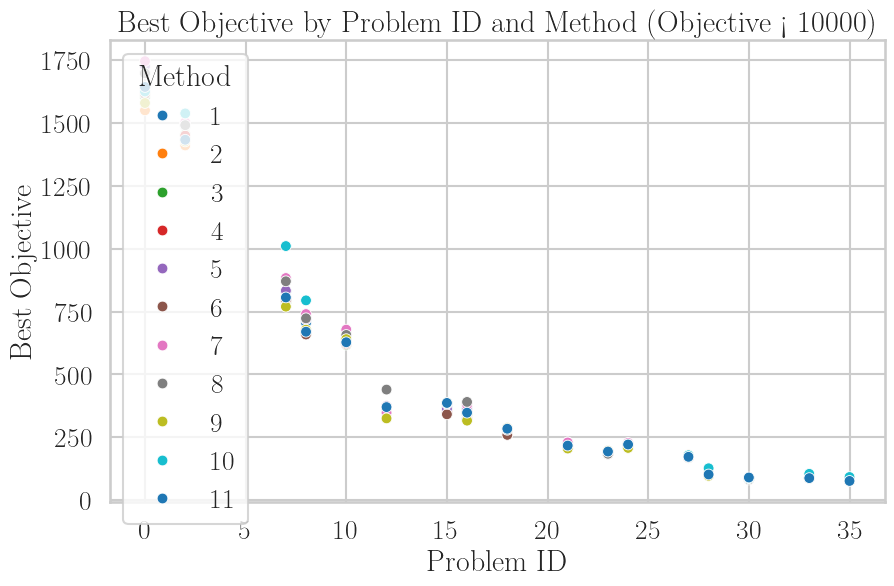

In [ ]:
for pid, group in df.groupby("problem_id"):
    if pid != 28:
        continue
    # if pid not in [0, 2, 7, 8, 10, 12, 15, 16, 18, 21, 23, 24, 27, 28, 30, 33, 35]:
    #     continue
    plt.figure(figsize=(10,6))
    for method in group['method'].values:
        
        df_filtered = df0 = group[group["method"] == method]
        # time = list(df_filtered['solution_log'])
        # print(list(df['solution_log'].apply(lambda lst: [t[0] for t in lst])))
        sol_log = list(df_filtered['solution_log'].apply(lambda s: [t for t in ast.literal_eval(s)]))[0]
        # display(sol_log)
        method_labels = {0: "NDS1", 1: "NDS2", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO"}
        plt.plot(
            [s[0] for s in sol_log if s[2] < min(10000, 2*s[2])],
            [s[2] for s in sol_log if s[2] < min(10000, 2*s[2])],
            alpha=1,
            label=method_labels.get(method, f"Method {method}")
        )
        plt.legend(fontsize=18)
    # plt.title(f'problem {pid}')

    plt.title('Heuristic Algorithms on a 40 Station Problem', fontsize=18, fontweight='bold', fontname='Arial')
    plt.xlabel('Time (s)', fontsize=18, fontname='Arial', fontweight='bold')
    plt.xticks(fontsize=18, fontname='Arial')
    plt.yticks(fontsize=18, fontname='Arial', fontweight='bold')
    plt.ylabel('Objective Value (hrs)', fontsize=18, fontname='Arial', fontweight='bold')
    plt.xlim([-50, 1250])
    plt.show()

display(df[df['best_obj'] == 10000])

df_plot = df[df["best_obj"] < 10000]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x="problem_id", y="best_obj", hue="method", palette="tab10", s=60)
plt.title("Best Objective by Problem ID and Method (Objective < 10000)")
plt.xlabel("Problem ID")
plt.ylabel("Best Objective")
plt.legend(title="Method")
plt.show()


In [ ]:
# df[df['method'] == 8].sort_values(by='problem_id')
df.value_counts('method')

method
0     17
1     17
2     17
3     17
4     17
5     17
6     17
7     17
8     17
9     17
10     8
Name: count, dtype: int64

In [ ]:
# display(df_mip[list(set(df.columns).intersection(set(df_mip.columns)))])
# print(list(set(df.columns).intersection(set(df_mip.columns))))
for col in df.columns:
    if col not in df_mip.columns:
        df_mip[col] = -1

# Concatenate and fill missing columns with -1
result = pd.concat([df, df_mip[df_mip["percentage_kept"] == 50]], ignore_index=True).fillna(-1)
for pid, group in result.groupby("problem_id"):
    if pid not in [0, 2, 7, 8, 10, 12, 15, 16, 18, 21, 23, 24, 27, 28, 30, 33, 35]:
        continue
    dfm = group[group["method"] == -1]
    df0 = group[group["method"] == 0]
    df1 = group[group["method"] == 1]
    df2 = group[group["method"] == 2]
    df3 = group[group["method"] == 3]
    df4 = group[group["method"] == 4]
    plt.scatter(dfm["problem_id"], dfm["best_obj"], marker='x')
    plt.scatter(df0["problem_id"], df0["best_obj"], c='blue')
    plt.scatter(df1["problem_id"], df1["best_obj"], c='red')
    plt.scatter(df2["problem_id"], df2["best_obj"], c='yellow')
    plt.scatter(df3["problem_id"], df3["best_obj"], c='green')
    plt.scatter(df4["problem_id"], df4["best_obj"], c='black')
    plt.show()

NameError: name 'df_mip' is not defined

C:\Users\saahi\AppData\Local\Temp\ipykernel_22808\724463589.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_heur = df_heur[df_heur['best_obj'] < 10000][df_heur['method'].isin(methods_list)]
C:\Users\saahi\AppData\Local\Temp\ipykernel_22808\724463589.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mip = df_mip[df_mip['problem_id'].isin([0, 2, 7, 8, 10, 12, 15, 16, 18, 21, 23, 24, 27, 28, 30, 33, 35])][df_mip["percentage_kept"] > 1]


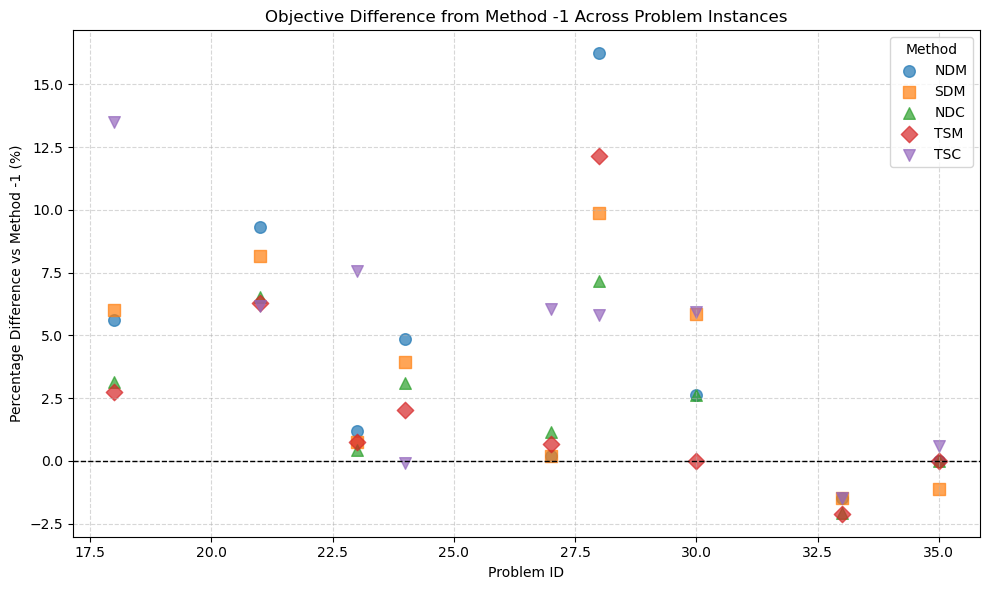

{'whiskers': [<matplotlib.lines.Line2D at 0x2270f89dd10>,
 'caps': [<matplotlib.lines.Line2D at 0x2270f89df90>,
 'boxes': [<matplotlib.lines.Line2D at 0x2270f89dbd0>],
 'medians': [<matplotlib.lines.Line2D at 0x2270f89e210>],
 'fliers': [<matplotlib.lines.Line2D at 0x2270f89e350>],
 'means': []}

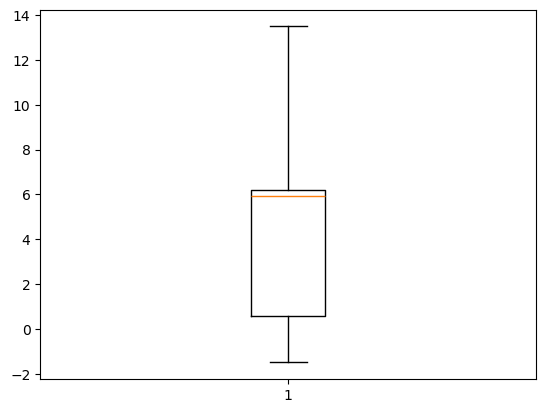

In [ ]:
df_heur = df_orig.copy()
df_mip = df_mip_orig.copy()
methods_list = [2, 3, 4, 6, 9]
df_heur = df_heur[df_heur['best_obj'] < 10000][df_heur['method'].isin(methods_list)]
df_heur = df_heur[df_heur['problem_id'].isin([0, 2, 7, 8, 10, 12, 15, 16, 18, 21, 23, 24, 27, 28, 30, 33, 35])]
df_mip = df_mip[df_mip['problem_id'].isin([0, 2, 7, 8, 10, 12, 15, 16, 18, 21, 23, 24, 27, 28, 30, 33, 35])][df_mip["percentage_kept"] > 1]

df_mip_valid = df_mip[df_mip["best_obj"].notna()].copy()

# 2. Find row in df_mip with lowest best_obj per problem_id
df_mip_best = df_mip_valid.loc[
    df_mip_valid.groupby("problem_id")["best_obj"].idxmin()
].copy()

# 3. Set method = -1 for the new rows
df_mip_best["method"] = -1

# 4. Add any columns from df_heur that are missing in df_mip_best
for col in df_heur.columns:
    if col not in df_mip_best.columns:
        # fill with matching values from df_heur for same problem_id (take first occurrence)
        df_mip_best[col] = df_mip_best["problem_id"].map(
            df_heur.groupby("problem_id")[col].first()
        )

# 5. Align columns and append to df_heur
df_mip_best = df_mip_best[df_heur.columns]  # same column order as df_heur
df_combined = pd.concat([df_heur, df_mip_best], ignore_index=True)

# 6. Optional: sort by problem_id for clarity
df_combined = df_combined.sort_values("problem_id").reset_index(drop=True)

ref = (
    df_combined[df_combined["method"] == -1]
    .set_index("problem_id")["best_obj"]
    .rename("ref_obj")
)

# Merge reference onto all rows
df_plot = df_combined.merge(ref, on="problem_id", how="left")

# Keep only rows where ref_obj exists (non-NaN)
df_plot = df_plot[df_plot["ref_obj"].notna()]

# Compute percentage difference
df_plot["pct_diff"] = 100 * (df_plot["best_obj"] - df_plot["ref_obj"]) / df_plot["ref_obj"]

# Drop rows where method == -1 (since diff = 0 trivially)
df_plot = df_plot[df_plot["method"] != -1]

# --- Plot ---
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10,6))

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', 'H']
method_labels = {0: "NDS1", 1: "NDS", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO"}

for i, (method, data) in enumerate(sorted(df_plot.groupby("method"))):
    ax.scatter(
        data["problem_id"],
        data["pct_diff"],
        label=method_labels.get(method, f"Method {method}"),
        marker=markers[i % len(markers)],
        s=70,
        alpha=0.7
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Problem ID")
ax.set_ylabel("Percentage Difference vs Method -1 (%)")
ax.set_title("Objective Difference from Method -1 Across Problem Instances")
ax.legend(title="Method", ) #, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.boxplot(data['pct_diff'])


# markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', 'H']

# plt.style.use('default')
# fig, ax = plt.subplots(figsize=(10,6))

# # Sort methods for consistent ordering
# for i, (method, data) in enumerate(sorted(df_combined.groupby("method"))):
#     ax.scatter(
#         data["problem_id"],
#         data["best_obj"],
#         label=f"Method {method}",
#         marker=markers[i % len(markers)],
#         s=70,
#         alpha=0.5
#     )
# # ax.set_yscale('log')
# ax.set_xlabel("Problem ID")
# ax.set_ylabel("Best Objective Value")
# ax.set_title("Best Objective by Problem ID and Method")
# ax.legend(title="Method", bbox_to_anchor=(1.05, 1), loc="upper left")
# ax.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()
    